# EDA — league_model

Exploración de `riot_dataset/features.csv` (una fila por **minuto × partida**).

**Contexto:** el modelo está estancado en **AUC ~0.868**. Cuatro palancas agotadas
(datos 12x, tuning, LSTM, features nuevas del timeline) → el techo parece intrínseco.
`gold_diff` **él solo** ya saca 0.844.

**Preguntas de este EDA:**
1. ¿Cómo son las distribuciones?
2. ⭐ **¿Cambia el poder predictivo de cada variable según el minuto?** (un barón al 20 ≠ al 40)
3. ¿Cuánta colinealidad hay? ¿Qué podamos?
4. ¿Está **calibrado** el modelo? (que un 70% gane el 70%)
5. ¿Es estable entre parches?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (11, 4)

df = pd.read_csv('../riot_dataset/features.csv')
print(df.shape)
df.head()

(230210, 32)


,match_id,patch,minute,blue_win,gold_diff,xp_diff,cs_diff,kills_diff,tower_diff,inhib_diff,...,xp_diff_JGL,gold_diff_MID,xp_diff_MID,gold_diff_BOT,xp_diff_BOT,gold_diff_SUP,xp_diff_SUP,gold_diff_d5,xp_diff_d5,kills_diff_d5
0,EUW1_7880487704,16.11,5,1,-393,392,3,-1,0,0,...,7,579,454,-961,-258,28,65,0,0,0
1,EUW1_7880487704,16.11,6,1,199,791,9,0,0,0,...,59,814,474,-915,-29,143,39,0,0,0
2,EUW1_7880487704,16.11,7,1,-31,756,6,0,0,0,...,80,921,753,-1017,20,112,-283,0,0,0
3,EUW1_7880487704,16.11,8,1,-422,736,7,-1,0,0,...,541,933,846,-1206,-20,74,-323,0,0,0
4,EUW1_7880487704,16.11,9,1,-862,110,7,-2,0,0,...,331,663,535,-1080,207,10,-500,0,0,0


## 1. Panorama general

In [2]:
print('Filas          :', len(df))
print('Partidas       :', df.match_id.nunique())
print('Balance blue_win:', round(df.blue_win.mean(), 4))
print('Minutos        :', df.minute.min(), '->', df.minute.max())
print('\nPartidas por parche:')
print(df.groupby('patch').match_id.nunique().sort_index())
print('\nDuración de partida (minutos por game):')
print(df.groupby('match_id').minute.max().describe())

Filas          : 230210
Partidas       : 9839
Balance blue_win: 0.5179
Minutos        : 5 -> 58

Partidas por parche:
patch
16.11       6
16.12     175
16.13    7963
16.14    1695
Name: match_id, dtype: int64

Duración de partida (minutos por game):
count    9839.000000
mean       27.397703
std         6.034922
min         5.000000
25%        24.000000
50%        27.000000
75%        31.000000
max        58.000000
Name: minute, dtype: float64


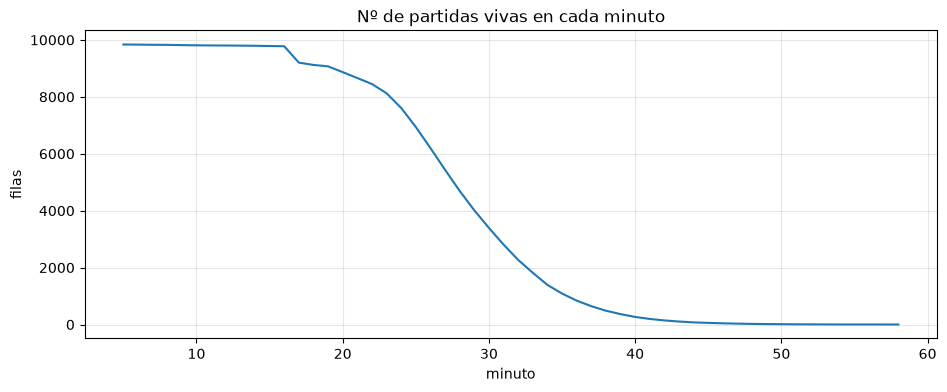

In [3]:
# cuántas filas sobreviven a cada minuto (las partidas largas son minoría)
counts = df.groupby('minute').size()
counts.plot(title='Nº de partidas vivas en cada minuto', xlabel='minuto', ylabel='filas')
plt.grid(alpha=.3); plt.show()

## 2. Distribuciones

`gold_diff` separado por resultado, en varios minutos. Debe verse cómo las dos
campanas se separan a medida que avanza la partida.

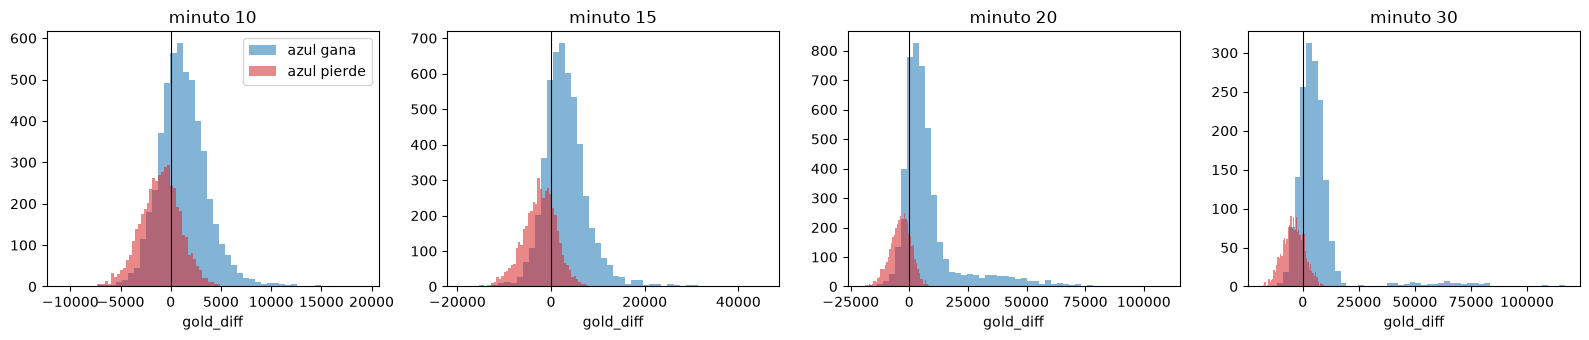

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, m in zip(axes, [10, 15, 20, 30]):
    d = df[df.minute == m]
    for win, label, color in [(1, 'azul gana', 'tab:blue'), (0, 'azul pierde', 'tab:red')]:
        ax.hist(d[d.blue_win == win].gold_diff, bins=50, alpha=.55, label=label, color=color)
    ax.set_title(f'minuto {m}'); ax.set_xlabel('gold_diff'); ax.axvline(0, color='k', lw=.8)
axes[0].legend()
plt.tight_layout(); plt.show()

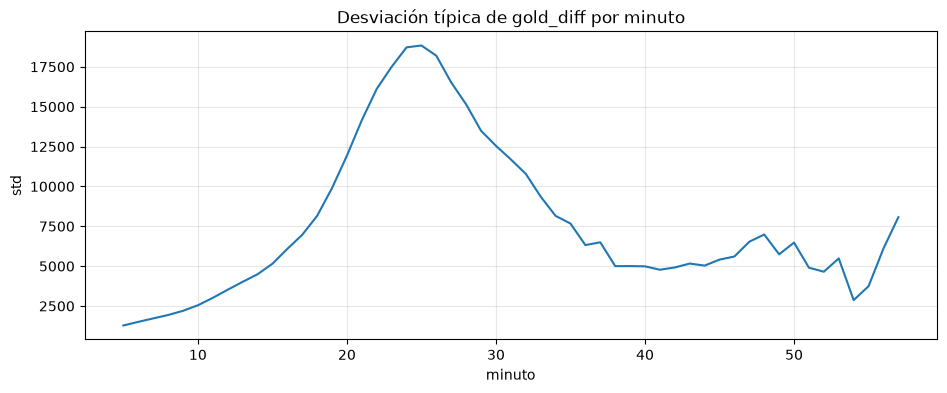

In [5]:
# ¿Cuánto se dispersa la ventaja de oro con el tiempo?
df.groupby('minute').gold_diff.std().plot(
    title='Desviación típica de gold_diff por minuto', xlabel='minuto', ylabel='std')
plt.grid(alpha=.3); plt.show()

## 3. ⭐ Poder predictivo por minuto

**La pregunta clave:** ¿vale lo mismo un barón al minuto 20 que al 40?

Para cada feature y cada minuto calculamos el **AUC de esa variable sola** contra
`blue_win`. Es una medida limpia de "cuánta información lleva esta variable *en
este instante*".

> Nota: se usa `max(auc, 1-auc)` para ignorar el signo, y se salta cualquier
> minuto donde la variable sea constante (p.ej. `baron_diff` es 0 en todas las
> partidas antes del ~min 20 → no se puede medir AUC ahí).

In [6]:
def auc_por_minuto(df, col, minutos=range(5, 41), min_filas=200):
    """AUC de una feature sola contra blue_win, minuto a minuto."""
    out = {}
    for m in minutos:
        d = df[df.minute == m]
        if len(d) < min_filas or d.blue_win.nunique() < 2 or d[col].std() == 0:
            continue
        a = roc_auc_score(d.blue_win, d[col])
        out[m] = max(a, 1 - a)
    return pd.Series(out)

FEATS = ['gold_diff', 'kills_diff', 'tower_diff', 'inhib_diff',
         'dragon_diff', 'herald_diff', 'baron_diff', 'grub_diff',
         'gold_diff_d5', 'cs_diff', 'xp_diff']
curvas = {c: auc_por_minuto(df, c) for c in FEATS}
tabla = pd.DataFrame(curvas)
tabla.round(3)

,gold_diff,kills_diff,tower_diff,inhib_diff,dragon_diff,herald_diff,baron_diff,grub_diff,gold_diff_d5,cs_diff,xp_diff
5,0.688,0.679,0.500,NaN,NaN,NaN,NaN,NaN,NaN,0.609,0.651
6,0.705,0.698,0.501,0.500,0.523,NaN,NaN,NaN,NaN,0.623,0.669
7,0.728,0.722,0.501,0.500,0.578,NaN,NaN,NaN,NaN,0.635,0.687
8,0.740,0.735,0.503,0.500,0.598,NaN,NaN,NaN,NaN,0.647,0.707
9,0.755,0.751,0.505,0.501,0.614,NaN,NaN,0.543,NaN,0.659,0.722
10,0.770,0.764,0.514,0.501,0.629,NaN,NaN,0.551,0.737,0.674,0.738
11,0.784,0.779,0.537,0.501,0.637,NaN,NaN,0.558,0.743,0.692,0.754
12,0.801,0.794,0.589,0.501,0.662,NaN,NaN,0.560,0.761,0.708,0.767
13,0.817,0.811,0.649,0.501,0.684,NaN,NaN,0.560,0.782,0.723,0.790
14,0.831,0.827,0.694,0.502,0.694,NaN,0.500,0.560,0.797,0.739,0.813


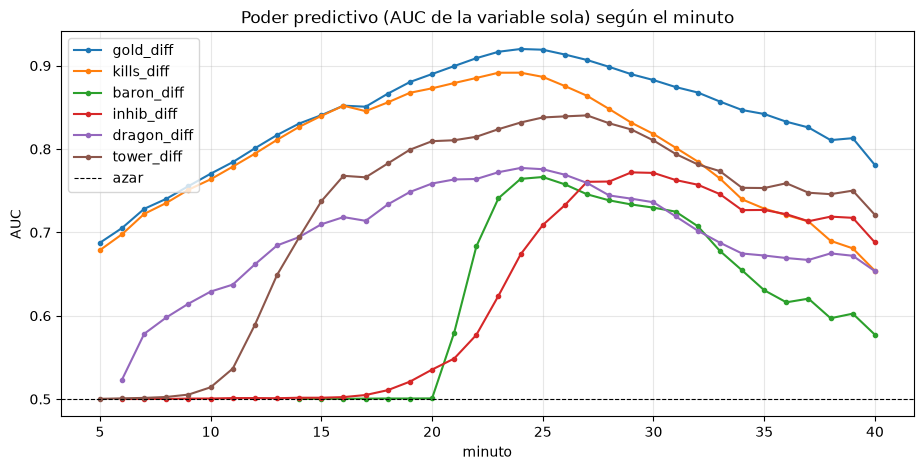

In [7]:
# La respuesta visual a la pregunta del barón
fig, ax = plt.subplots(figsize=(11, 5))
for c in ['gold_diff', 'kills_diff', 'baron_diff', 'inhib_diff', 'dragon_diff', 'tower_diff']:
    tabla[c].dropna().plot(ax=ax, marker='.', label=c)
ax.axhline(.5, color='k', ls='--', lw=.8, label='azar')
ax.set_title('Poder predictivo (AUC de la variable sola) según el minuto')
ax.set_xlabel('minuto'); ax.set_ylabel('AUC'); ax.legend(); ax.grid(alpha=.3)
plt.show()

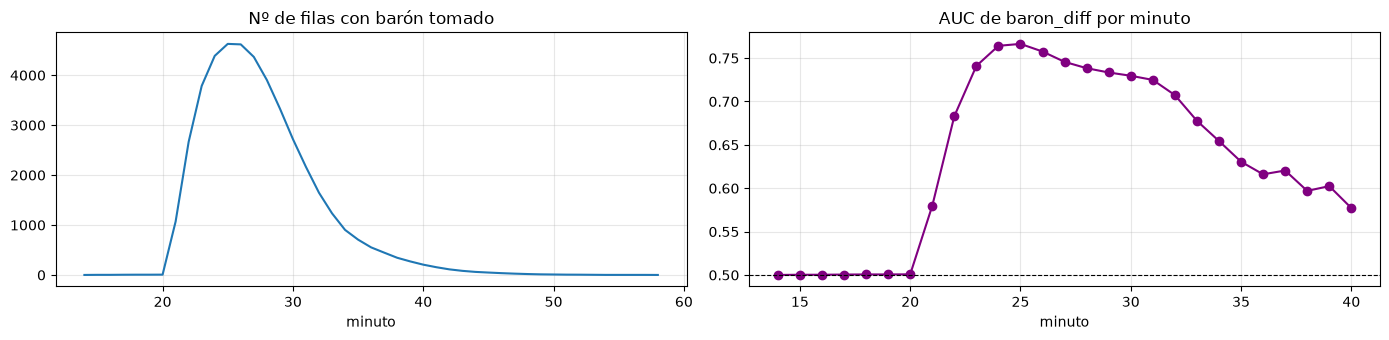

min 25: con barón de ventaja -> winrate 0.775  (n=2168)
min 30: con barón de ventaja -> winrate 0.705  (n=1314)
min 35: con barón de ventaja -> winrate 0.634  (n=347)
min 40: con barón de ventaja -> winrate 0.643  (n=84)


In [8]:
# El barón, en detalle: ¿en qué minuto aparece y cuánto informa?
b = df[df.baron_diff != 0].groupby('minute').size()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 3.5))
b.plot(ax=a1, title='Nº de filas con barón tomado', xlabel='minuto'); a1.grid(alpha=.3)
tabla['baron_diff'].dropna().plot(ax=a2, marker='o', color='purple',
                                   title='AUC de baron_diff por minuto', xlabel='minuto')
a2.axhline(.5, color='k', ls='--', lw=.8); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

# winrate condicionado: tener barón al min X, ¿cuánto te da?
for m in [20, 25, 30, 35, 40]:
    d = df[(df.minute == m) & (df.baron_diff > 0)]
    if len(d) > 30:
        print(f'min {m:>2}: con barón de ventaja -> winrate {d.blue_win.mean():.3f}  (n={len(d)})')

**Interpreta aquí:** si la curva de `baron_diff` sube/baja con el minuto, tu
intuición se confirma y tendría sentido una interacción explícita `baron × minuto`
(o modelos por fase). Si es plana, el valor del barón no depende del momento.

## 4. Colinealidad

Ya sospechamos que `gold/xp/cs/level` van muy de la mano. Aquí se cuantifica:
lo que esté muy correlacionado es candidato a podar.

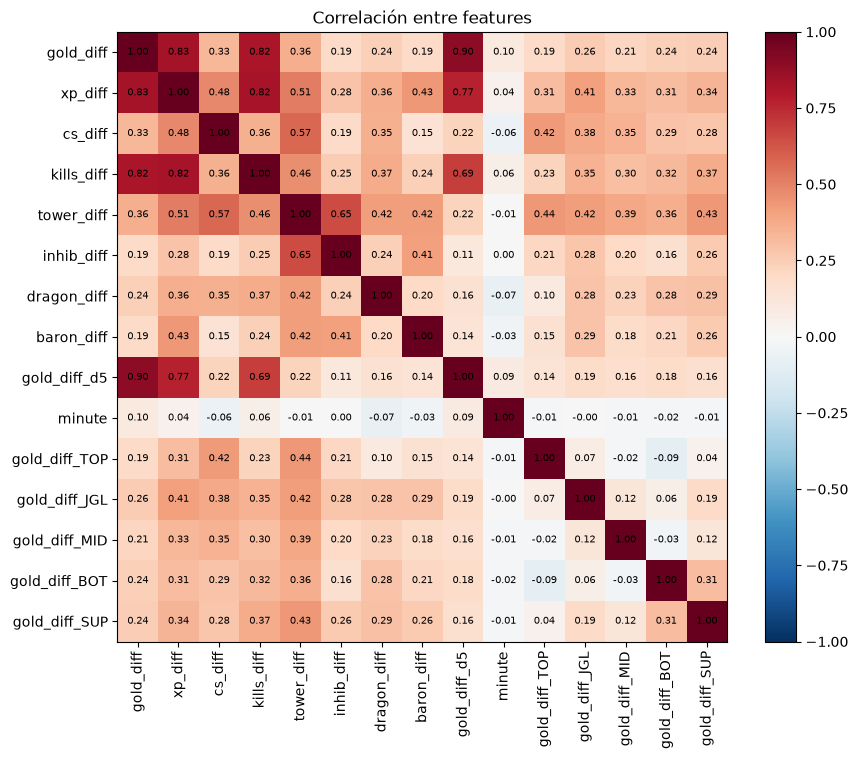

In [9]:
cols = ['gold_diff', 'xp_diff', 'cs_diff', 'kills_diff', 'tower_diff', 'inhib_diff',
        'dragon_diff', 'baron_diff', 'gold_diff_d5', 'minute',
        'gold_diff_TOP', 'gold_diff_JGL', 'gold_diff_MID', 'gold_diff_BOT', 'gold_diff_SUP']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im); plt.title('Correlación entre features'); plt.tight_layout(); plt.show()

In [10]:
# Poder predictivo global de cada feature sola (screening rápido)
filas = []
for c in df.columns:
    if c in ('match_id', 'patch', 'blue_win') or df[c].std() == 0:
        continue
    a = roc_auc_score(df.blue_win, df[c])
    filas.append({'feature': c, 'auc_solo': round(max(a, 1 - a), 4)})
pd.DataFrame(filas).sort_values('auc_solo', ascending=False).reset_index(drop=True)

,feature,auc_solo
0,gold_diff,0.8387
1,xp_diff,0.8207
2,kills_diff,0.8169
3,kills_diff_d5,0.7800
4,gold_diff_d5,0.7690
5,dmg_champs_diff,0.7631
6,xp_diff_d5,0.7548
7,tower_diff,0.7176
8,xp_diff_JGL,0.7173
9,cs_diff,0.7141


## 5. Calibración — lo que de verdad importa para un win%

El AUC mide **ordenar**. La calibración mide que el número **signifique** algo:
de todas las veces que el modelo dice 70%, ¿gana el 70%?

Para un producto de "probabilidad de ganar" esto importa **más** que el AUC.

In [11]:
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import calibration_curve

bundle = joblib.load('../models/modelo_baseline.joblib')
model, FEATURES = bundle['model'], bundle['features']

# mismo split por partida que en el entrenamiento
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_, test_idx = next(gss.split(df[FEATURES].values, df.blue_win.values, df.match_id.values))
te = df.iloc[test_idx]
proba = model.predict_proba(te[FEATURES].values)[:, 1]
print('Test:', len(te), 'filas /', te.match_id.nunique(), 'partidas')

Test: 46213 filas / 1968 partidas


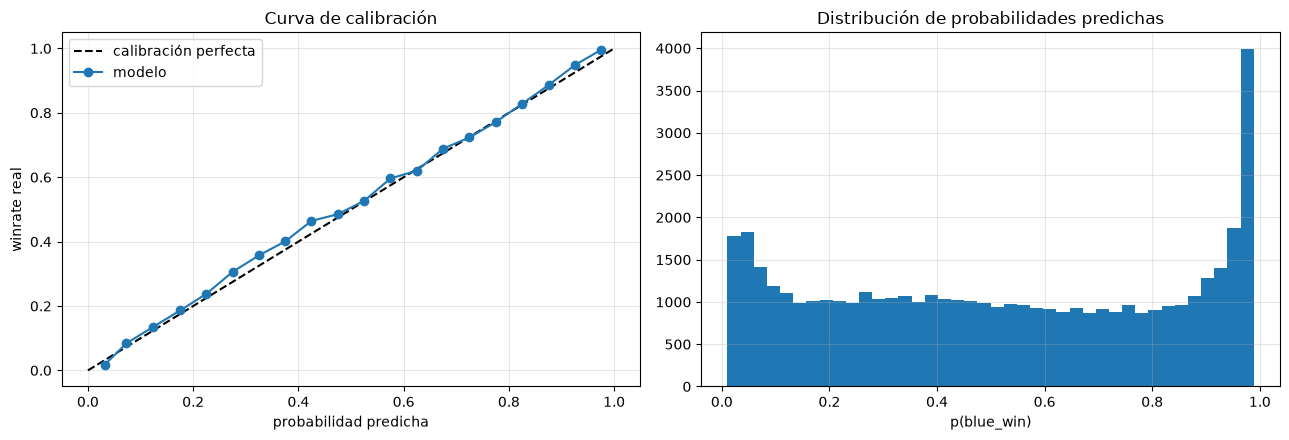

In [12]:
frac_pos, mean_pred = calibration_curve(te.blue_win, proba, n_bins=20)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot([0, 1], [0, 1], 'k--', label='calibración perfecta')
a1.plot(mean_pred, frac_pos, 'o-', label='modelo')
a1.set_xlabel('probabilidad predicha'); a1.set_ylabel('winrate real')
a1.set_title('Curva de calibración'); a1.legend(); a1.grid(alpha=.3)
a2.hist(proba, bins=40); a2.set_title('Distribución de probabilidades predichas')
a2.set_xlabel('p(blue_win)'); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

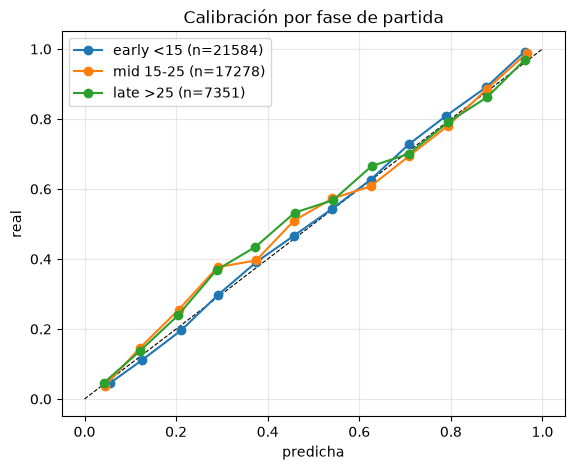

In [13]:
# Calibración POR FASE: ¿miente más en early o en late?
t = te.copy(); t['proba'] = proba
t['fase'] = pd.cut(t.minute, [0, 15, 25, 200], labels=['early <15', 'mid 15-25', 'late >25'])
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=.8)
for fase, g in t.groupby('fase', observed=True):
    fp, mp = calibration_curve(g.blue_win, g.proba, n_bins=12)
    ax.plot(mp, fp, 'o-', label=f'{fase} (n={len(g)})')
ax.set_xlabel('predicha'); ax.set_ylabel('real'); ax.legend()
ax.set_title('Calibración por fase de partida'); ax.grid(alpha=.3)
plt.show()

## 6. Estabilidad entre parches

Test empírico de que el modelo es **agnóstico a la versión**: si la relación
`gold_diff → winrate` se solapa entre parches, queda demostrado.

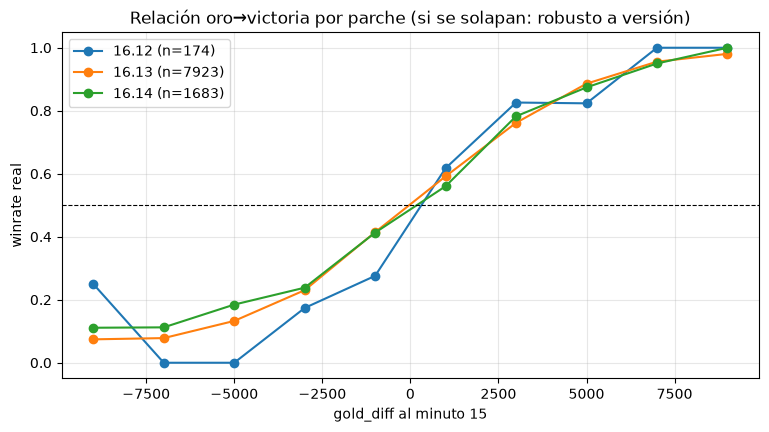

In [14]:
d = df[df.minute == 15].copy()
d['bucket'] = pd.cut(d.gold_diff, np.arange(-10000, 10001, 2000))

fig, ax = plt.subplots(figsize=(9, 4.5))
for patch, g in d.groupby('patch'):
    if g.match_id.nunique() < 100:
        continue
    wr = g.groupby('bucket', observed=True).blue_win.mean()
    ax.plot([b.mid for b in wr.index], wr.values, 'o-', label=f'{patch} (n={g.match_id.nunique()})')
ax.axhline(.5, color='k', ls='--', lw=.8)
ax.set_xlabel('gold_diff al minuto 15'); ax.set_ylabel('winrate real')
ax.set_title('Relación oro→victoria por parche (si se solapan: robusto a versión)')
ax.legend(); ax.grid(alpha=.3)
plt.show()